In [1]:
import pandas as pd

# Loading the CSV
df = pd.read_csv("../data/tfl_road_status.csv")

df.head()

,road,status,description,timestamp
0,A13,Good,No Exceptional Delays,2025-05-05T14:55:27.111477
1,A2,Good,No Exceptional Delays,2025-05-05T14:55:27.111484
2,North Circular (A406),Good,No Exceptional Delays,2025-05-05T14:55:27.111486
3,A13,Good,No Exceptional Delays,2025-05-05T15:07:28.693118
4,A2,Good,No Exceptional Delays,2025-05-05T15:07:28.693127


In [2]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   road         52 non-null     object        
 1   status       52 non-null     object        
 2   description  52 non-null     object        
 3   timestamp    52 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ KB


In [3]:
df['status'].value_counts()


status
Good       46
Serious     6
Name: count, dtype: int64

In [4]:
df['description'].value_counts()


description
No Exceptional Delays    46
Serious Delays            6
Name: count, dtype: int64

/var/folders/ng/1q_6q8_n1fx35q947ctj0w1m0000gn/T/ipykernel_11677/624543916.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df.set_index('timestamp').resample('H').size().plot(figsize=(12, 4), title="Number of Traffic Samples Per Hour")


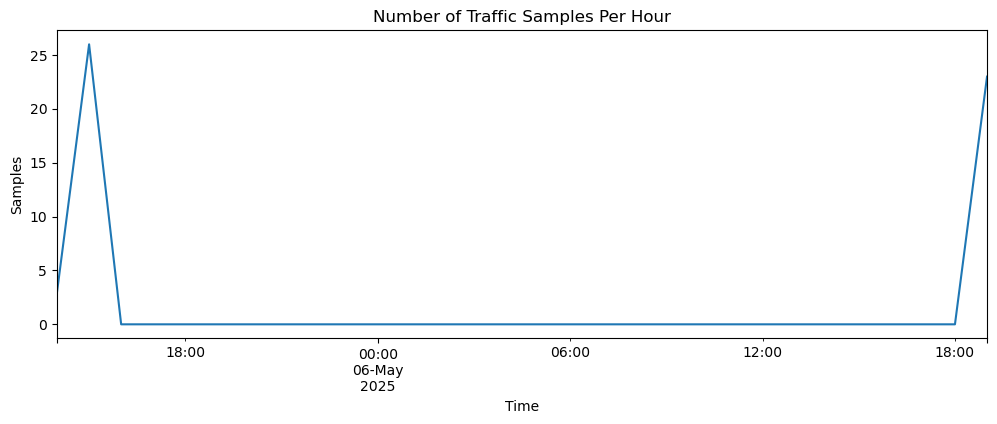

In [5]:
import matplotlib.pyplot as plt

# Number of rows collected over time
df.set_index('timestamp').resample('H').size().plot(figsize=(12, 4), title="Number of Traffic Samples Per Hour")
plt.xlabel("Time")
plt.ylabel("Samples")
plt.show()


In [6]:
pivot = df.pivot_table(index='timestamp', columns='road', values='status', aggfunc='first')
pivot.head()


road,A1,A10,A12,A13,A2,A20,A21,A23,A24,A3,...,A41,Bishopsgate Cross Route,Blackwall Tunnel,City Route,Farringdon Cross Route,Inner Ring,North Circular (A406),South Circular (A205),Southern River Route,Western Cross Route
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-05-05 14:55:27.111477,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-05 14:55:27.111484,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-05 14:55:27.111486,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN
2025-05-05 15:07:28.693118,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-05-05 15:07:28.693127,NaN,NaN,NaN,NaN,Good,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
severity_map = {
    'Good': 0,
    'Minor Delays': 1,
    'Serious Delays': 2,
    'Severe Delays': 3,
    'No Exceptional Delays': 0
}
df['severity_level'] = df['status'].map(severity_map)

In [8]:
df.to_csv("../data/cleaned_tfl_road_status.csv", index=False)


Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   road         52 non-null     object        
 1   status       52 non-null     object        
 2   description  52 non-null     object        
 3   timestamp    52 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 1.8+ KB

First few rows:
                    road status            description  \
0                    A13   Good  No Exceptional Delays   
1                     A2   Good  No Exceptional Delays   
2  North Circular (A406)   Good  No Exceptional Delays   
3                    A13   Good  No Exceptional Delays   
4                     A2   Good  No Exceptional Delays   

                   timestamp  
0 2025-05-05 14:55:27.111477  
1 2025-05-05 14:55:27.111484  
2 2025-05-05 14:55:27.111486  
3 2025-05-05 15:07:28.693118  
4 2025-05-05 

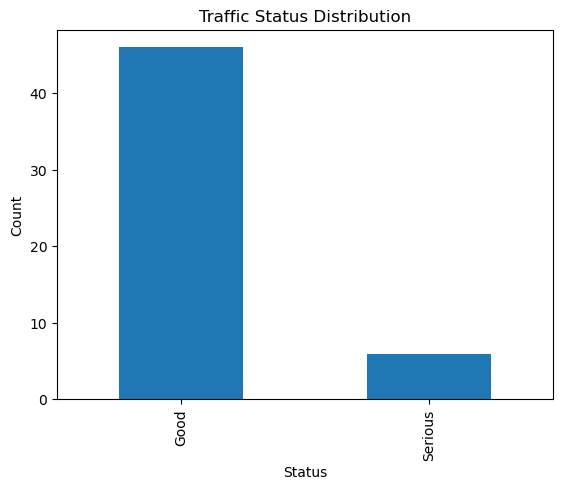

<Figure size 1200x600 with 0 Axes>

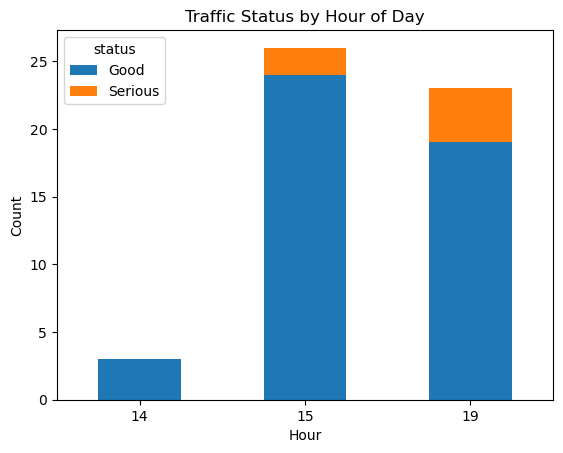

<Figure size 1200x600 with 0 Axes>

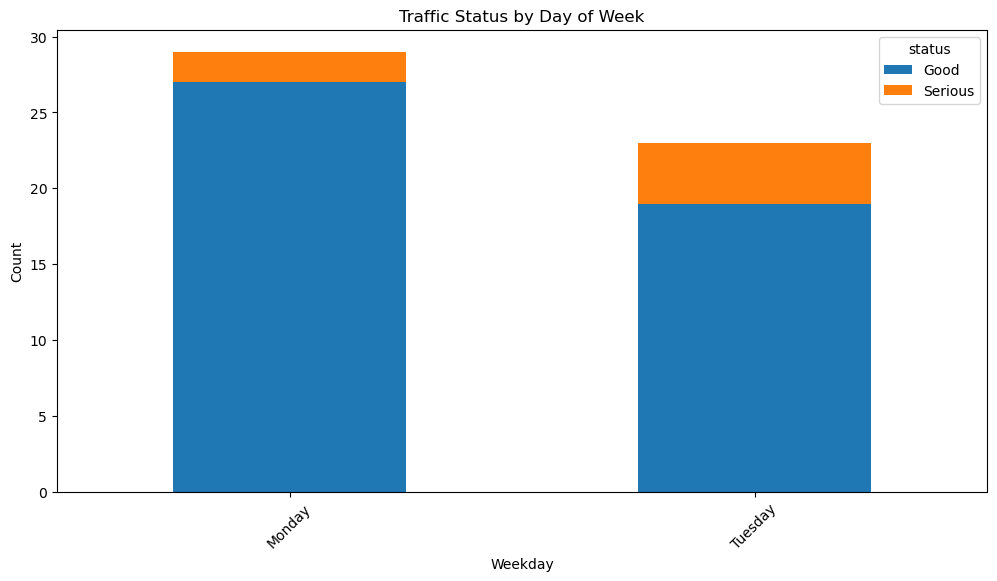

Cleaned data saved


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/tfl_road_status.csv")

# Converting timestamp column to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Inspecting data
print("Data info:")
df.info()

print("\nFirst few rows:")
print(df.head())

# checking for missing values
print("\nMissing values:")
print(df.isnull().sum())

# checking for duplicates
print("\nDuplicates:")
print(df.duplicated().sum())

# count observations per road
print("\nRoad observation counts:")
print(df['road'].value_counts())

# traffic status distribution
df['status'].value_counts().plot(kind='bar', title="Traffic Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# Extract time-based features
df['hour'] = df['timestamp'].dt.hour
df['weekday'] = df['timestamp'].dt.day_name()

# traffic status by hour of day
plt.figure(figsize=(12, 6))
df.groupby('hour')['status'].value_counts().unstack().plot(kind='bar', stacked=True)
plt.title("Traffic Status by Hour of Day")
plt.ylabel("Count")
plt.xlabel("Hour")
plt.xticks(rotation=0)
plt.show()

# traffic status by day of week
plt.figure(figsize=(12, 6))
df.groupby('weekday')['status'].value_counts().unstack().plot(
    kind='bar', stacked=True, figsize=(12, 6)
)

plt.title("Traffic Status by Day of Week")
plt.ylabel("Count")
plt.xlabel("Weekday")
plt.xticks(rotation=45)
plt.show()

# Saving cleaned version with new columns
df.to_csv("../data/cleaned_tfl_road_status.csv", index=False)
print("Cleaned data saved")
